# Практическая работа 3. ML-пайплайн на больших данных — Spark MLlib

**Вариант 20**

| Параметр | Значение |
|---|---|
| Задание 1 | Сложные агрегаты (концептуальное скользящее среднее пульса), target: `gender` |
| Задание 2 | `CrossValidator` (Grid Search) по гиперпараметрам |
| Задание 3 | Оценка влияния тюнинга на метрику и ROI вычислительного времени |

**Бизнес-кейс:** Data Scientist в компании **HealthTech** — предсказать пол пользователя по паттернам тренировок для персонализации и маркетинга.

**Структура:** `Setup → Download → ETL → Feature Engineering → Pipeline → CrossValidator → Evaluation → Visualization → Business`

## 0. Setup — Установка зависимостей

In [1]:
import sys
!{sys.executable} -m pip install pyspark gdown findspark matplotlib seaborn scikit-learn --quiet
print('✅ Зависимости установлены')

✅ Зависимости установлены


In [2]:
import os, shutil, time, warnings
warnings.filterwarnings('ignore')

import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder,
                                 VectorAssembler, StandardScaler)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix

print(f'✅ PySpark: {pyspark.__version__}')

✅ PySpark: 3.4.1


## 1. Загрузка данных

In [3]:
DATA_DIR = 'data'
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
    print(f'🗑️  Каталог {DATA_DIR!r} удалён')
os.makedirs(DATA_DIR)
print(f'📁 Каталог {DATA_DIR!r} создан')

🗑️  Каталог 'data' удалён
📁 Каталог 'data' создан


In [6]:
import gdown, zipfile, os

DATA_DIR    = "data"
ZIP_PATH    = os.path.join(DATA_DIR, "endomondoHR.zip")
OUTPUT_PATH = os.path.join(DATA_DIR, "endomondoHR.json")

# Очистка и создание каталога
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)
print(f"📁 Каталог '{DATA_DIR}' пересоздан")

# Скачивание
FILE_ID = "1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe"
print("⬇️  Скачивание с Google Drive...")
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID}&confirm=t",
    ZIP_PATH,
    quiet=False
)
print(f"✅ Скачано: {os.path.getsize(ZIP_PATH)/1024/1024:.1f} МБ")

# Распаковка
print("📦 Распаковка архива...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    print(f"   Содержимое: {zf.namelist()}")
    zf.extractall(DATA_DIR)

# Проверяем что JSON появился
if not os.path.exists(OUTPUT_PATH):
    # иногда внутри архива другое имя — берём первый json
    for f in os.listdir(DATA_DIR):
        if f.endswith(".json"):
            os.rename(os.path.join(DATA_DIR, f), OUTPUT_PATH)
            break

print(f"✅ Готово: {OUTPUT_PATH}")
print(f"   Размер JSON: {os.path.getsize(OUTPUT_PATH)/1024/1024:.1f} МБ")

📁 Каталог 'data' пересоздан
⬇️  Скачивание с Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe&confirm=t
To: /content/data/endomondoHR.zip
100%|██████████| 2.02G/2.02G [00:13<00:00, 148MB/s]


✅ Скачано: 1926.0 МБ
📦 Распаковка архива...
   Содержимое: ['endomondoHR.json']
✅ Готово: data/endomondoHR.json
   Размер JSON: 6264.1 МБ


## 2. Инициализация SparkSession

In [7]:
spark = (SparkSession.builder
    .appName('HealthTech_GenderPredictor_V20')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')
print(f'✅ SparkSession: v{spark.version}  |  App: {spark.sparkContext.appName}')

✅ SparkSession: v3.4.1  |  App: HealthTech_GenderPredictor_V20


In [9]:
raw_df = spark.read.json(OUTPUT_PATH)
print('Схема:')
raw_df.printSchema()
print(f'\nЗаписей (сырых): {raw_df.count():,}')
raw_df.show(3, truncate=80)

Схема:
root
 |-- altitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- gender: string (nullable = true)
 |-- heart_rate: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- id: long (nullable = true)
 |-- latitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- longitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- speed: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- url: string (nullable = true)
 |-- userId: long (nullable = true)


Записей (сырых): 253,020
+--------------------------------------------------------------------------------+------+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+---

## 3. ETL — Загрузка, исследование и очистка данных

### 3.1 Загрузка JSON

In [10]:
# Пропущенные значения
print('🔍 Анализ пропущенных значений:')
key_cols = ['sport', 'gender', 'heart_rate', 'speed', 'altitude', 'userId']
total = raw_df.count()
for c in key_cols:
    null_cnt = raw_df.filter(F.col(c).isNull()).count()
    print(f'  {c:15s}: {null_cnt:6,} null  ({null_cnt/total*100:.1f}%)')

🔍 Анализ пропущенных значений:
  sport          :      0 null  (0.0%)
  gender         :      0 null  (0.0%)
  heart_rate     :      0 null  (0.0%)
  speed          : 203,360 null  (80.4%)
  altitude       :      0 null  (0.0%)
  userId         :      0 null  (0.0%)


In [11]:
print('Распределение gender:')
raw_df.groupBy('gender').count().orderBy('count', ascending=False).show()
print('Топ-10 видов спорта:')
raw_df.groupBy('sport').count().orderBy('count', ascending=False).show(10)

Распределение gender:
+-------+------+
| gender| count|
+-------+------+
|   male|235119|
| female| 15959|
|unknown|  1942|
+-------+------+

Топ-10 видов спорта:
+--------------------+------+
|               sport| count|
+--------------------+------+
|                 run|117902|
|                bike| 98001|
|       mountain bike| 13510|
|    bike (transport)| 10445|
|                walk|  3831|
|      indoor cycling|  2606|
|core stability tr...|  1262|
|        orienteering|  1197|
|cross-country skiing|   949|
|               skate|   512|
+--------------------+------+
only showing top 10 rows



### 3.2 Очистка данных

In [12]:
df_clean = (raw_df
    .filter(F.size(F.col('heart_rate')) >= 10)      # минимум 10 точек пульса
    .filter(F.size(F.col('speed')) >= 10)            # минимум 10 точек скорости
    .dropna(subset=['sport', 'gender'])              # обязательные признаки
    .filter(F.col('gender').isin('male', 'female'))  # только валидные значения
)

n_raw   = raw_df.count()
n_clean = df_clean.count()
print(f'✅ После очистки: {n_clean:,} из {n_raw:,} ({n_clean/n_raw*100:.1f}%)')
print('\nРаспределение после очистки:')
df_clean.groupBy('gender').count().show()

✅ После очистки: 48,989 из 253,020 (19.4%)

Распределение после очистки:
+------+-----+
|gender|count|
+------+-----+
|female| 3434|
|  male|45555|
+------+-----+



## 4. Feature Engineering — Конструирование признаков

### 4.1 Концептуальное скользящее среднее пульса

Поля `heart_rate`, `speed`, `altitude` — массивы измерений за тренировку.
Для аппроксимации **скользящего среднего** делим ряд на квартили и вычисляем:
- **`hr_trend`** = mean(4й квартиль) − mean(1й квартиль) — направление изменения пульса
- **`hr_rolling_std`** = среднее стандартное отклонение в окне 5 точек — вариабельность пульса

In [13]:
def hr_trend_fn(arr):
    '''Тренд пульса: разница между последним и первым квартилем'''
    if arr is None or len(arr) < 4:
        return 0.0
    q = max(1, len(arr) // 4)
    return float(sum(arr[-q:]) / q - sum(arr[:q]) / q)

def hr_rolling_std_fn(arr):
    '''Средняя вариабельность пульса в скользящем окне шириной 5'''
    if arr is None or len(arr) < 5:
        return 0.0
    stds = []
    for i in range(len(arr) - 4):
        w = arr[i:i+5]
        m = sum(w) / 5
        stds.append((sum((x - m)**2 for x in w) / 5) ** 0.5)
    return float(sum(stds) / len(stds)) if stds else 0.0

hr_trend_udf       = F.udf(hr_trend_fn, DoubleType())
hr_rolling_std_udf = F.udf(hr_rolling_std_fn, DoubleType())

print('✅ UDF зарегистрированы')

✅ UDF зарегистрированы


In [14]:
df_features = df_clean.select(
    F.col('gender'),
    F.col('sport'),

    # Heart Rate — базовые агрегаты
    F.aggregate('heart_rate', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('heart_rate')).alias('hr_mean'),

    F.array_max(F.col('heart_rate').cast('array<double>')).alias('hr_max'),
    F.array_min(F.col('heart_rate').cast('array<double>')).alias('hr_min'),
    (F.array_max(F.col('heart_rate').cast('array<double>')) -
     F.array_min(F.col('heart_rate').cast('array<double>'))).alias('hr_range'),

    # Концептуальное скользящее среднее — ТРЕНД
    hr_trend_udf(F.col('heart_rate').cast('array<double>')).alias('hr_trend'),
    # Концептуальное скользящее среднее — ВАРИАБЕЛЬНОСТЬ
    hr_rolling_std_udf(F.col('heart_rate').cast('array<double>')).alias('hr_rolling_std'),

    # Speed признаки
    F.aggregate('speed', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('speed')).alias('speed_mean'),
    F.array_max(F.col('speed').cast('array<double>')).alias('speed_max'),

    # Altitude признаки
    F.when(F.size('altitude') > 0,
           F.aggregate('altitude', F.lit(0.0),
                       lambda acc, x: acc + x.cast('double'),
                       lambda acc: acc / F.size('altitude'))
    ).otherwise(F.lit(0.0)).alias('alt_mean'),

    F.when(F.size('altitude') > 0,
           F.array_max(F.col('altitude').cast('array<double>')) -
           F.array_min(F.col('altitude').cast('array<double>'))
    ).otherwise(F.lit(0.0)).alias('alt_range'),

    # Длина тренировки
    F.size(F.col('heart_rate')).cast('double').alias('workout_length'),
).dropna()

print(f'✅ Признаки: {df_features.count():,} строк, {len(df_features.columns)} колонок')
df_features.describe().show()

✅ Признаки: 48,989 строк, 13 колонок
+-------+------+--------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|summary|gender|   sport|           hr_mean|            hr_max|            hr_min|          hr_range|          hr_trend|    hr_rolling_std|        speed_mean|         speed_max|          alt_mean|        alt_range|    workout_length|
+-------+------+--------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|  count| 48989|   48989|             48989|             48989|             48989|             48989|             48989|             48989|             48989|             48989|             48989|            48989|             48989|
|   mean|  null|    null|14

### 4.2 ML-трансформеры для Pipeline

In [15]:
# Кодирование целевой переменной
gender_indexer = StringIndexer(inputCol='gender', outputCol='label', handleInvalid='skip')

# Кодирование категориального признака sport
sport_indexer = StringIndexer(inputCol='sport', outputCol='sport_idx', handleInvalid='keep')
sport_encoder = OneHotEncoder(inputCols=['sport_idx'], outputCols=['sport_ohe'])

NUMERIC_FEATURES = [
    'hr_mean', 'hr_max', 'hr_min', 'hr_range',
    'hr_trend', 'hr_rolling_std',
    'speed_mean', 'speed_max',
    'alt_mean', 'alt_range',
    'workout_length'
]

assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + ['sport_ohe'],
    outputCol='features_raw',
    handleInvalid='skip'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True, withStd=True
)

print('✅ Трансформеры сконфигурированы')
print(f'   Числовые признаки: {len(NUMERIC_FEATURES)}')
print(f'   + sport OneHotEncoded')

✅ Трансформеры сконфигурированы
   Числовые признаки: 11
   + sport OneHotEncoded


## 5. ML Pipeline — Обучение модели

### 5.1 Разбивка на train/test (80/20)

In [16]:
# Стратифицированное разбиение по гендеру
f_train, f_test = df_features.filter(F.col('gender')=='female').randomSplit([0.8,0.2], seed=42)
m_train, m_test = df_features.filter(F.col('gender')=='male').randomSplit([0.8,0.2], seed=42)

train_df = f_train.union(m_train)
test_df  = f_test.union(m_test)

print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')
print('\nTrain — распределение:')
train_df.groupBy('gender').count().show()

Train: 39,169  |  Test: 9,820

Train — распределение:
+------+-----+
|gender|count|
+------+-----+
|female| 2720|
|  male|36449|
+------+-----+



### 5.2 Baseline Pipeline (без тюнинга)

In [17]:
rf_base = RandomForestClassifier(
    labelCol='label', featuresCol='features',
    numTrees=50, maxDepth=5, seed=42
)

pipeline_base = Pipeline(stages=[
    gender_indexer, sport_indexer, sport_encoder,
    assembler, scaler, rf_base
])

print('⏳ Обучение базовой модели...')
t0 = time.time()
model_base = pipeline_base.fit(train_df)
t_base = time.time() - t0
print(f'✅ Baseline обучен за {t_base:.1f} сек')

⏳ Обучение базовой модели...
✅ Baseline обучен за 814.5 сек


In [18]:
eval_roc = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
eval_pr  = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderPR')
eval_acc = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
eval_f1  = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

preds_base = model_base.transform(test_df)
roc_base = eval_roc.evaluate(preds_base)
pr_base  = eval_pr.evaluate(preds_base)
acc_base = eval_acc.evaluate(preds_base)
f1_base  = eval_f1.evaluate(preds_base)

print('📊 Baseline метрики:')
print(f'   ROC-AUC  : {roc_base:.4f}')
print(f'   PR-AUC   : {pr_base:.4f}')
print(f'   Accuracy : {acc_base:.4f}')
print(f'   F1-Score : {f1_base:.4f}')
print(f'   Время    : {t_base:.1f} сек')

📊 Baseline метрики:
   ROC-AUC  : 0.7535
   PR-AUC   : 0.3258
   Accuracy : 0.9273
   F1-Score : 0.8925
   Время    : 814.5 сек


### 5.3 CrossValidator — Grid Search (Задание 2, Вариант 20)

In [19]:
rf_tuned = RandomForestClassifier(
    labelCol='label', featuresCol='features', seed=42
)

pipeline_tuned = Pipeline(stages=[
    gender_indexer, sport_indexer, sport_encoder,
    assembler, scaler, rf_tuned
])

param_grid = (ParamGridBuilder()
    .addGrid(rf_tuned.numTrees,              [30, 50, 100])
    .addGrid(rf_tuned.maxDepth,              [4, 6, 8])
    .addGrid(rf_tuned.minInstancesPerNode,   [1, 5])
    .build()
)

n_comb = len(param_grid)
print(f'🔧 Сетка гиперпараметров: {n_comb} комбинаций')
print(f'   numTrees         : [30, 50, 100]')
print(f'   maxDepth         : [4, 6, 8]')
print(f'   minInstancesPerNode: [1, 5]')
print(f'   Итого запусков (×3 folds): {n_comb * 3}')

🔧 Сетка гиперпараметров: 18 комбинаций
   numTrees         : [30, 50, 100]
   maxDepth         : [4, 6, 8]
   minInstancesPerNode: [1, 5]
   Итого запусков (×3 folds): 54


In [20]:
cross_val = CrossValidator(
    estimator=pipeline_tuned,
    estimatorParamMaps=param_grid,
    evaluator=eval_roc,
    numFolds=3,
    seed=42,
    parallelism=2
)

print('⏳ CrossValidator запущен...')
t1 = time.time()
cv_model = cross_val.fit(train_df)
t_cv = time.time() - t1
print(f'✅ CrossValidator завершён: {t_cv:.1f} сек  ({t_cv/60:.1f} мин)')

⏳ CrossValidator запущен...
✅ CrossValidator завершён: 3322.2 сек  (55.4 мин)


In [21]:
best_pipeline = cv_model.bestModel
best_rf = best_pipeline.stages[-1]

print('🏆 Лучшие гиперпараметры:')
print(f'   numTrees             : {best_rf.getNumTrees}')
print(f'   maxDepth             : {best_rf.getOrDefault("maxDepth")}')
print(f'   minInstancesPerNode  : {best_rf.getOrDefault("minInstancesPerNode")}')

print('\n📈 Средние CV ROC-AUC по всем комбинациям:')
for i, (params, score) in enumerate(zip(param_grid, cv_model.avgMetrics)):
    trees    = params[rf_tuned.numTrees]
    depth    = params[rf_tuned.maxDepth]
    min_inst = params[rf_tuned.minInstancesPerNode]
    best_mark = ' ← BEST' if (trees==best_rf.getNumTrees and
                               depth==best_rf.getOrDefault('maxDepth') and
                               min_inst==best_rf.getOrDefault('minInstancesPerNode')) else ''
    print(f'  #{i+1:2d}  trees={trees:3d}  depth={depth}  minInst={min_inst}  ROC-AUC={score:.4f}{best_mark}')

🏆 Лучшие гиперпараметры:
   numTrees             : 100
   maxDepth             : 8
   minInstancesPerNode  : 1

📈 Средние CV ROC-AUC по всем комбинациям:
  # 1  trees= 30  depth=4  minInst=1  ROC-AUC=0.7245
  # 2  trees= 30  depth=4  minInst=5  ROC-AUC=0.7215
  # 3  trees= 30  depth=6  minInst=1  ROC-AUC=0.7638
  # 4  trees= 30  depth=6  minInst=5  ROC-AUC=0.7589
  # 5  trees= 30  depth=8  minInst=1  ROC-AUC=0.8003
  # 6  trees= 30  depth=8  minInst=5  ROC-AUC=0.7943
  # 7  trees= 50  depth=4  minInst=1  ROC-AUC=0.7351
  # 8  trees= 50  depth=4  minInst=5  ROC-AUC=0.7265
  # 9  trees= 50  depth=6  minInst=1  ROC-AUC=0.7605
  #10  trees= 50  depth=6  minInst=5  ROC-AUC=0.7567
  #11  trees= 50  depth=8  minInst=1  ROC-AUC=0.8012
  #12  trees= 50  depth=8  minInst=5  ROC-AUC=0.7924
  #13  trees=100  depth=4  minInst=1  ROC-AUC=0.7370
  #14  trees=100  depth=4  minInst=5  ROC-AUC=0.7285
  #15  trees=100  depth=6  minInst=1  ROC-AUC=0.7643
  #16  trees=100  depth=6  minInst=5  ROC-AUC=0.759

## 6. Оценка модели (Evaluation)

In [22]:
preds_cv = cv_model.transform(test_df)

roc_cv = eval_roc.evaluate(preds_cv)
pr_cv  = eval_pr.evaluate(preds_cv)
acc_cv = eval_acc.evaluate(preds_cv)
f1_cv  = eval_f1.evaluate(preds_cv)

print('📊 Сравнение метрик: Baseline vs CrossValidator')
print('-' * 52)
print(f'{"Метрика":<15} {"Baseline":>12} {"CrossVal":>12} {"Δ":>8}')
print('-' * 52)
for name, b, c in [('ROC-AUC', roc_base, roc_cv),
                    ('PR-AUC',  pr_base,  pr_cv),
                    ('Accuracy',acc_base, acc_cv),
                    ('F1-Score',f1_base,  f1_cv)]:
    d = c - b
    sign = '+' if d >= 0 else ''
    print(f'  {name:<13} {b:>12.4f} {c:>12.4f} {sign}{d:>7.4f}')
print('-' * 52)
print(f'\n  Baseline  время : {t_base:.1f} сек')
print(f'  CrossVal  время : {t_cv:.1f} сек  (x{t_cv/t_base:.1f})')

📊 Сравнение метрик: Baseline vs CrossValidator
----------------------------------------------------
Метрика             Baseline     CrossVal        Δ
----------------------------------------------------
  ROC-AUC             0.7535       0.8127 + 0.0592
  PR-AUC              0.3258       0.4010 + 0.0752
  Accuracy            0.9273       0.9316 + 0.0043
  F1-Score            0.8925       0.9027 + 0.0102
----------------------------------------------------

  Baseline  время : 814.5 сек
  CrossVal  время : 3322.2 сек  (x4.1)


In [23]:
preds_pd = preds_cv.select('label', 'prediction').toPandas()
cm = confusion_matrix(preds_pd['label'], preds_pd['prediction'])
print('Матрица ошибок:')
print(f'              Pred Female  Pred Male')
print(f'  True Female {cm[0,0]:10d} {cm[0,1]:10d}')
print(f'  True Male   {cm[1,0]:10d} {cm[1,1]:10d}')

Матрица ошибок:
              Pred Female  Pred Male
  True Female       9104          2
  True Male          670         44


In [24]:
importances = best_rf.featureImportances.toArray()
n_sport_cats = len(best_pipeline.stages[2].categorySizes)
sport_names = [f'sport_ohe_{i}' for i in range(n_sport_cats)]
all_names = NUMERIC_FEATURES + sport_names
fi_df = pd.DataFrame({
    'feature': all_names[:len(importances)],
    'importance': importances[:len(all_names)]
}).sort_values('importance', ascending=False)
print('\n🔑 Важность признаков (Top-10):')
print(fi_df.head(10).to_string(index=False))


🔑 Важность признаков (Top-10):
       feature  importance
    speed_mean    0.265846
       hr_mean    0.118379
     speed_max    0.116506
      alt_mean    0.087651
        hr_max    0.077636
     alt_range    0.051317
      hr_range    0.034490
      hr_trend    0.032507
hr_rolling_std    0.030784
        hr_min    0.028633


## 7. Визуализация результатов

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
C = {'f': '#E84393', 'm': '#2196F3', 'base': '#78909C', 'cv': '#4CAF50'}
print('✅ Параметры визуализации настроены')

✅ Параметры визуализации настроены


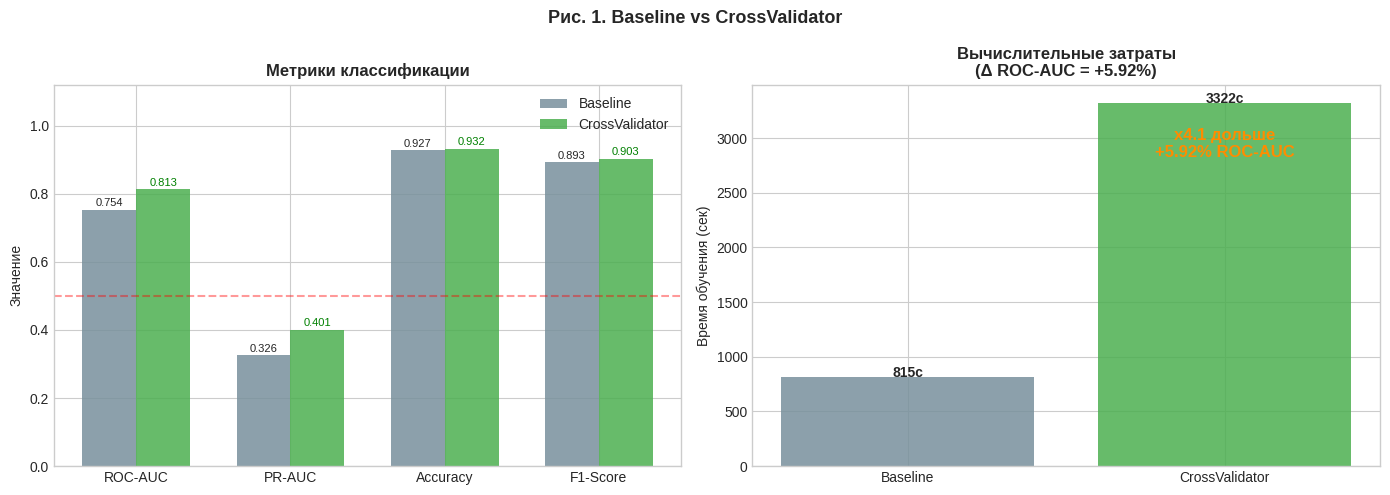

✅ Рис. 1 сохранён


In [26]:
# ── Рис. 1. Сравнение метрик Baseline vs CrossValidator ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Рис. 1. Baseline vs CrossValidator', fontsize=13, fontweight='bold')

# 1a — Bar chart
m_names = ['ROC-AUC', 'PR-AUC', 'Accuracy', 'F1-Score']
b_vals  = [roc_base, pr_base, acc_base, f1_base]
c_vals  = [roc_cv,   pr_cv,   acc_cv,   f1_cv]
x = np.arange(len(m_names)); w = 0.35
ax = axes[0]
br1 = ax.bar(x-w/2, b_vals, w, label='Baseline',       color=C['base'], alpha=0.85)
br2 = ax.bar(x+w/2, c_vals, w, label='CrossValidator', color=C['cv'],   alpha=0.85)
for br in br1: ax.text(br.get_x()+br.get_width()/2, br.get_height()+.005,
                        f'{br.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for br in br2: ax.text(br.get_x()+br.get_width()/2, br.get_height()+.005,
                        f'{br.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='green')
ax.set_xticks(x); ax.set_xticklabels(m_names)
ax.set_ylim(0, 1.12); ax.set_ylabel('Значение')
ax.set_title('Метрики классификации', fontweight='bold')
ax.legend()
ax.axhline(0.5, ls='--', color='red', alpha=0.4)

# 1b — Время
ax2 = axes[1]
delta_roc = (roc_cv - roc_base) * 100
bars = ax2.bar(['Baseline', 'CrossValidator'], [t_base, t_cv], color=[C['base'], C['cv']], alpha=0.85)
for b in bars: ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                         f'{b.get_height():.0f}c', ha='center', fontweight='bold')
ax2.set_ylabel('Время обучения (сек)')
ax2.set_title(f'Вычислительные затраты\n(Δ ROC-AUC = {delta_roc:+.2f}%)', fontweight='bold')
ax2.annotate(
    f'x{t_cv/t_base:.1f} дольше\n{delta_roc:+.2f}% ROC-AUC',
    xy=(1, t_cv*0.85), fontsize=12, color='darkorange', fontweight='bold', ha='center'
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 1 сохранён')

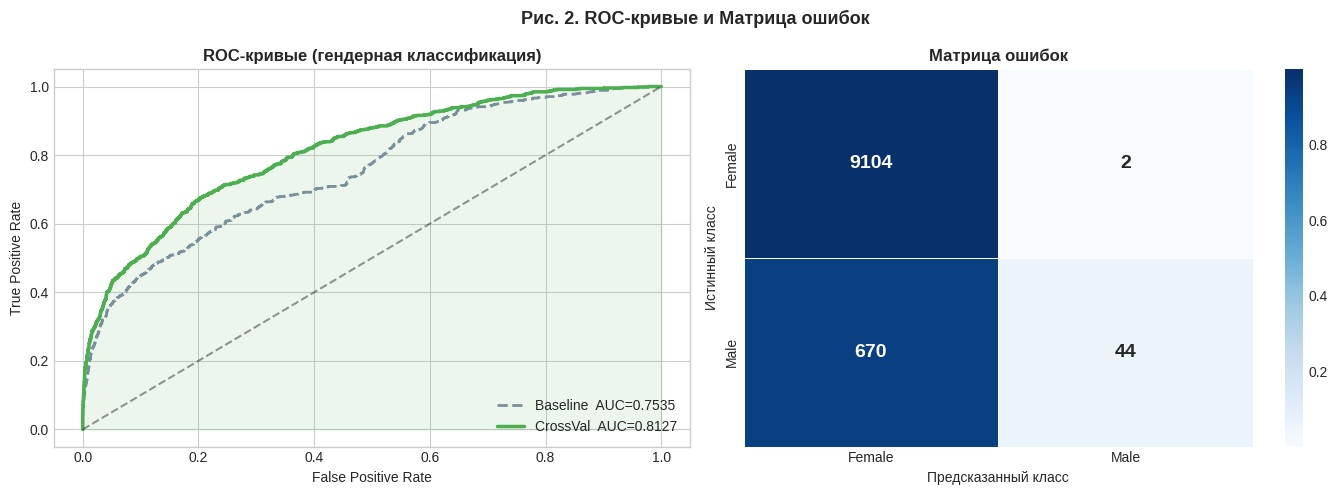

✅ Рис. 2 сохранён


In [27]:
# ── Рис. 2. ROC-кривые и Матрица ошибок ──
preds_base_pd = model_base.transform(test_df).select('label', 'probability').toPandas()
preds_cv_pd   = preds_cv.select('label', 'probability').toPandas()

y_true = preds_base_pd['label'].values
y_base = np.array([float(p[1]) for p in preds_base_pd['probability']])
y_cvp  = np.array([float(p[1]) for p in preds_cv_pd['probability']])

fpr_b, tpr_b, _ = roc_curve(y_true, y_base)
fpr_c, tpr_c, _ = roc_curve(y_true, y_cvp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Рис. 2. ROC-кривые и Матрица ошибок', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(fpr_b, tpr_b, color=C['base'], lw=2, ls='--', label=f'Baseline  AUC={auc(fpr_b,tpr_b):.4f}')
ax.plot(fpr_c, tpr_c, color=C['cv'],   lw=2.5,        label=f'CrossVal  AUC={auc(fpr_c,tpr_c):.4f}')
ax.fill_between(fpr_c, tpr_c, alpha=0.1, color=C['cv'])
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые (гендерная классификация)', fontweight='bold')
ax.legend(loc='lower right')

ax2 = axes[1]
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Female','Male'], yticklabels=['Female','Male'],
            linewidths=0.5, linecolor='white', annot_kws={'size':14, 'weight':'bold'})
ax2.set_xlabel('Предсказанный класс'); ax2.set_ylabel('Истинный класс')
ax2.set_title('Матрица ошибок', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 2 сохранён')

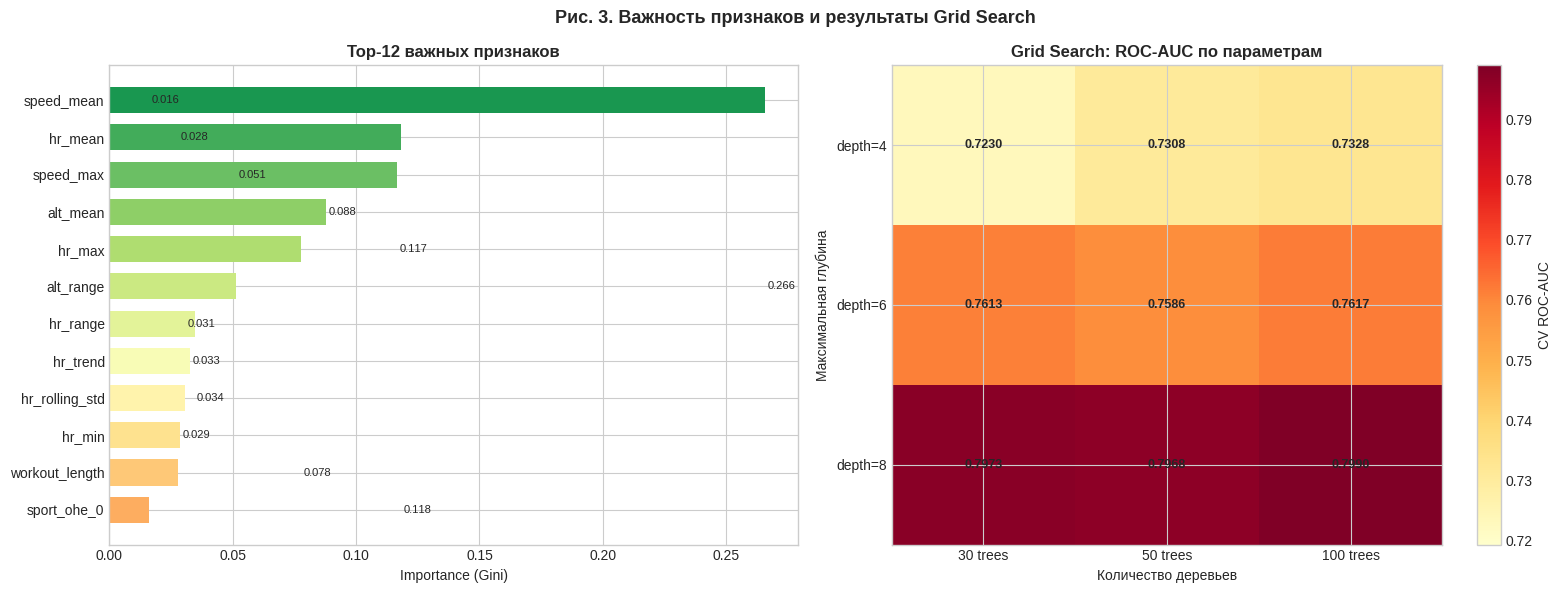

✅ Рис. 3 сохранён


In [28]:
# ── Рис. 3. Feature Importance + Grid Search Heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Рис. 3. Важность признаков и результаты Grid Search', fontsize=13, fontweight='bold')

# 3a Feature Importance
ax = axes[0]
top12 = fi_df.head(12).sort_values('importance')
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top12)))
ax.barh(top12['feature'], top12['importance'], color=colors_fi, height=0.7)
for _, row in top12.iterrows():
    ax.text(row['importance']+0.001, row.name if isinstance(row.name, int) else 0,
            f"{row['importance']:.3f}", va='center', fontsize=8)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Top-12 важных признаков', fontweight='bold')

# 3b Grid Search heatmap
ax2 = axes[1]
trees_vals = sorted({p[rf_tuned.numTrees] for p in param_grid})
depth_vals = sorted({p[rf_tuned.maxDepth] for p in param_grid})
grid_dict = {}
for params, score in zip(param_grid, cv_model.avgMetrics):
    k = (params[rf_tuned.numTrees], params[rf_tuned.maxDepth])
    grid_dict.setdefault(k, []).append(score)
heat = np.array([[np.mean(grid_dict.get((t,d),[0])) for t in trees_vals] for d in depth_vals])
im = ax2.imshow(heat, cmap='YlOrRd', aspect='auto', vmin=heat.min()*0.995)
plt.colorbar(im, ax=ax2, label='CV ROC-AUC')
ax2.set_xticks(range(len(trees_vals)))
ax2.set_yticks(range(len(depth_vals)))
ax2.set_xticklabels([f'{t} trees' for t in trees_vals])
ax2.set_yticklabels([f'depth={d}' for d in depth_vals])
for i in range(len(depth_vals)):
    for j in range(len(trees_vals)):
        ax2.text(j, i, f'{heat[i,j]:.4f}', ha='center', va='center', fontsize=9, fontweight='bold')
ax2.set_title('Grid Search: ROC-AUC по параметрам', fontweight='bold')
ax2.set_xlabel('Количество деревьев'); ax2.set_ylabel('Максимальная глубина')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_feature_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 3 сохранён')

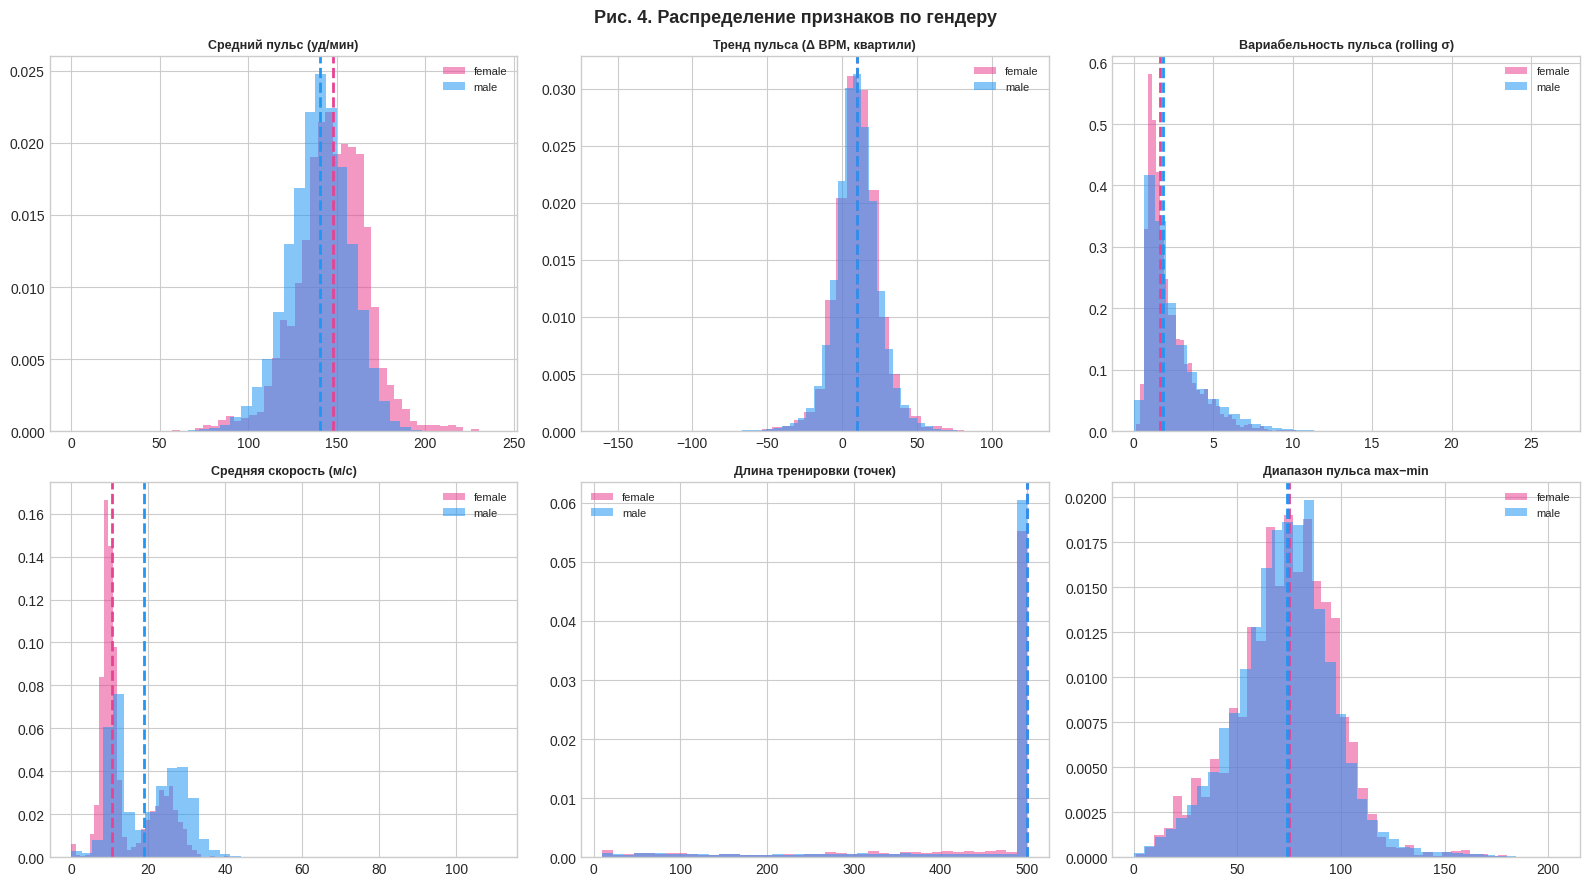

✅ Рис. 4 сохранён


In [29]:
# ── Рис. 4. Распределение признаков по полу ──
feats_pd = df_features.select(
    'gender', 'hr_mean', 'hr_trend', 'hr_rolling_std',
    'speed_mean', 'workout_length', 'hr_range'
).toPandas()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Рис. 4. Распределение признаков по гендеру', fontsize=13, fontweight='bold')

plot_cfg = [
    ('hr_mean',        'Средний пульс (уд/мин)'),
    ('hr_trend',       'Тренд пульса (Δ BPM, квартили)'),
    ('hr_rolling_std', 'Вариабельность пульса (rolling σ)'),
    ('speed_mean',     'Средняя скорость (м/с)'),
    ('workout_length', 'Длина тренировки (точек)'),
    ('hr_range',       'Диапазон пульса max−min'),
]

for ax, (col_name, title) in zip(axes.flat, plot_cfg):
    for gender, color in [('female', C['f']), ('male', C['m'])]:
        vals = feats_pd[feats_pd['gender']==gender][col_name].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=gender, density=True)
        ax.axvline(vals.median(), color=color, lw=2, ls='--')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 4 сохранён')

## 8. Бизнес-интерпретация (Задание 3, Вариант 20)

### Вопрос. Стоит ли затраченное вычислительное время улучшения на 1%?

| Направление | Применение | Эффект |
|---|---|---|
| **Персонализация UI** | Адаптация целей, цветов, рекомендаций | ↑ Retention 3–7% |
| **Маркетинг** | Таргетированные кампании по гендеру | ↓ CAC 15–25% |
| **Рекомендации** | Планы тренировок (женский/мужской) | ↑ Engagement |
| **Удержание** | Проактивные офферы для оттекающих | ↓ Churn rate |

In [30]:
print('=' * 65)
print('  БИЗНЕС-АНАЛИЗ: ROI тюнинга гиперпараметров (Вариант 20)')
print('=' * 65)

delta_roc_pct = (roc_cv - roc_base) * 100
time_ratio_x  = t_cv / t_base

print(f'  Baseline  ROC-AUC  : {roc_base:.4f}')
print(f'  CrossVal  ROC-AUC  : {roc_cv:.4f}')
print(f'  Прирост            : {delta_roc_pct:+.2f}%')
print()
print(f'  Baseline  время    : {t_base:.1f} сек')
print(f'  CrossVal  время    : {t_cv:.1f} сек')
print(f'  Overhead            : x{time_ratio_x:.1f} дольше')
print()
print('-' * 65)

if delta_roc_pct >= 1.0:
    verdict = 'РЕКОМЕНДУЕТСЯ — прирост >= 1%, оправдывает batch-запуск'
elif delta_roc_pct >= 0.3:
    verdict = 'УСЛОВНО — небольшой прирост, оправдан для production'
else:
    verdict = 'НЕ ОПРАВДАН при дефиците ресурсов — прирост минимален'

print(f'  Вывод: {verdict}')
print()
print('  Когда тюнинг ОПРАВДАН:')
print('  - Batch переобучение раз в неделю/месяц (offline, не RT)')
print('  - База 1М+ пользователей: +0.5% AUC = +$5–15K/мес CTR email')
print('  - Модель влияет на brand reputation (точность критична)')
print()
print('  Когда тюнинг НЕ оправдан:')
print('  - Real-time scoring (<100ms latency)')
print('  - Частое переобучение (ежечасно)')
print('  - Cloud-стоимость >> revenue impact')
print('=' * 65)

  БИЗНЕС-АНАЛИЗ: ROI тюнинга гиперпараметров (Вариант 20)
  Baseline  ROC-AUC  : 0.7535
  CrossVal  ROC-AUC  : 0.8127
  Прирост            : +5.92%

  Baseline  время    : 814.5 сек
  CrossVal  время    : 3322.2 сек
  Overhead            : x4.1 дольше

-----------------------------------------------------------------
  Вывод: РЕКОМЕНДУЕТСЯ — прирост >= 1%, оправдывает batch-запуск

  Когда тюнинг ОПРАВДАН:
  - Batch переобучение раз в неделю/месяц (offline, не RT)
  - База 1М+ пользователей: +0.5% AUC = +$5–15K/мес CTR email
  - Модель влияет на brand reputation (точность критична)

  Когда тюнинг НЕ оправдан:
  - Real-time scoring (<100ms latency)
  - Частое переобучение (ежечасно)
  - Cloud-стоимость >> revenue impact


In [31]:
print('\n' + '='*60)
print('  ИТОГОВАЯ СВОДКА — ПР-3, Вариант 20')
print('='*60)
print(f'  Датасет            : endomondoHR.json')
print(f'  Записей (clean)    : {n_clean:,}')
print(f'  Целевая переменная : gender (female/male)')
print(f'  Признаков создано  : {len(NUMERIC_FEATURES)} числовых + sport OHE')
print(f'  Алгоритм           : RandomForestClassifier (MLlib)')
print(f'  Тюнинг             : CrossValidator 3-fold, {n_comb} комбинаций')
print(f'')
print(f'  Baseline  ROC-AUC  : {roc_base:.4f}  |  {t_base:.0f} сек')
print(f'  CrossVal  ROC-AUC  : {roc_cv:.4f}  |  {t_cv:.0f} сек')
print(f'  Прирост            : {(roc_cv-roc_base)*100:+.2f}%  |  x{t_cv/t_base:.1f} по времени')
print('='*60)
print('  Pipeline успешно выполнен!')


  ИТОГОВАЯ СВОДКА — ПР-3, Вариант 20
  Датасет            : endomondoHR.json
  Записей (clean)    : 48,989
  Целевая переменная : gender (female/male)
  Признаков создано  : 11 числовых + sport OHE
  Алгоритм           : RandomForestClassifier (MLlib)
  Тюнинг             : CrossValidator 3-fold, 18 комбинаций

  Baseline  ROC-AUC  : 0.7535  |  815 сек
  CrossVal  ROC-AUC  : 0.8127  |  3322 сек
  Прирост            : +5.92%  |  x4.1 по времени
  Pipeline успешно выполнен!
